# Phase 1: Model Building (Task 1)
## a. Base Model 1: Hybrid CNN-LSTM Architecture
**Objective:** Construct a deep neural network combining Convolutional layers (for spatial feature extraction and noise reduction) with LSTM layers (for temporal sequence modeling). The network outputs a single probability indicating whether an engine is currently within the 30-cycle failure risk window.

In [49]:
#importing the need libraries

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization,Flatten, Add,Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
# import random

# # The "Triple Lock" for total consistency
# random.seed(42)
# np.random.seed(42)
# tf.random.set_seed(42)



In [3]:
#Load the 3D preprocced tensors
x_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')

print(f'Loaded x_train: {x_train.shape}')

Loaded x_train: (15731, 50, 14)


In [26]:
#1 Define the model Structure
def build_hybrid_cnn_lstm (sequence_length, num_features):
    model = Sequential([
        # CNN Block
        Input(shape =(sequence_length, num_features)),
        Conv1D(filters=64, kernel_size= 3, activation='relu',padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # LSTM Block
        LSTM(units = 100, return_sequences= True, activation='tanh'),
        Dropout(0.3),
        LSTM(units=50, return_sequences=False, activation='tanh'),
        Dropout(0.3),

        # classification Head
        Dense(units=32, activation='relu'),
        Dense(units =1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer = optimizer,loss = 'binary_crossentropy', metrics =['accuracy'])
    return model

#instantiate and summarise
model_a = build_hybrid_cnn_lstm(sequence_length=x_train.shape[1], num_features= x_train.shape[2])
model_a.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 25, 100)        │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 25, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,873 (394.04 KB)

 Trainable params: 100,745 (393.54 KB)

 Non-trainable params: 128 (512.00 B)

## basic Model Training & Validation (CNN-LSTM)
**Objective:** Train the Hybrid CNN-LSTM model using an 80/20 train-validation split. Implement an `EarlyStopping` callback to monitor validation loss, preventing the model from overfitting the training data by halting the process when generalization stops improving.

In [9]:
# 1 Configure Early Stopping
# This prevents the model from memorizing the data (overfitting)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,               # If validation loss doesn't improve for 5 epochs, stop.
    restore_best_weights=True # Keep the best performing weights, not the final epoch's weights
)

In [ ]:


# 2. Execute the Training Loop
print(" Starting Model Training on RTX 4050...")
history_a = model_a.fit(
    x_train, y_train,
    epochs=50,                # Max epochs (EarlyStopping will likely stop it sooner)
    batch_size=64,            # Number of sequences processed before updating weights
    validation_split=0.2,     # Automatically holds out the last 20% of data for validation
    callbacks=[early_stop],
    verbose=1
)
print(" Training Complete!")



 Starting Model Training on RTX 4050...
Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9452 - loss: 0.1428 - val_accuracy: 0.8278 - val_loss: 0.6306
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9662 - loss: 0.0800 - val_accuracy: 0.9031 - val_loss: 0.1765
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9708 - loss: 0.0713 - val_accuracy: 0.9673 - val_loss: 0.0769
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9786 - loss: 0.0514 - val_accuracy: 0.9501 - val_loss: 0.1697
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9775 - loss: 0.0549 - val_accuracy: 0.9425 - val_loss: 0.1434
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9817 - loss: 0.0426 - val_accuracy: 0.9581 - val_loss: 0.1108
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9841 - loss: 0.0394 - val_accuracy: 0.9406 - val_loss: 0.1066
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - a

# Ploting the results

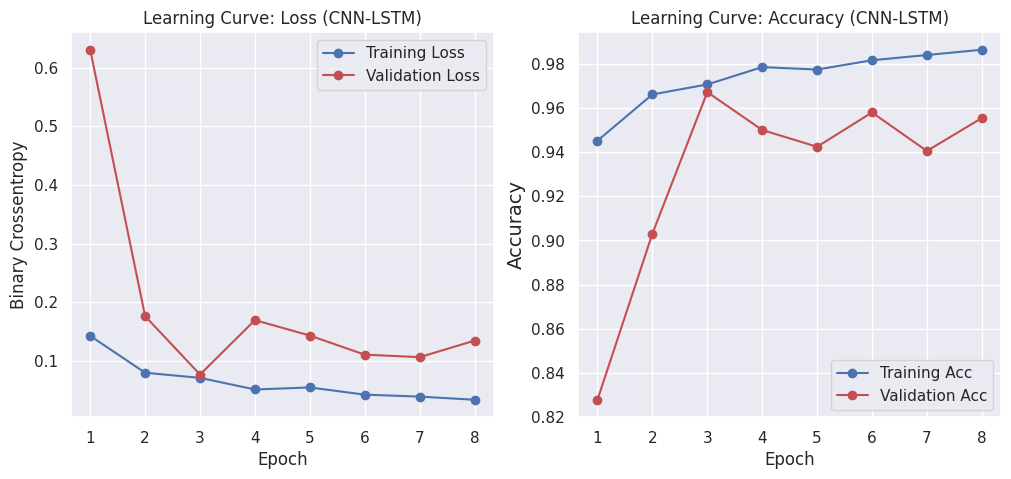

In [38]:


def plot_learning_curves(history_a):
    loss = history_a.history['loss']
    val_loss = history_a.history['val_loss']
    acc = history_a.history['accuracy']
    val_acc = history_a.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    # Plot 2: Loss (The Signal)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Learning Curve: Loss (CNN-LSTM)')
    plt.ylabel('Binary Crossentropy')
    plt.xlabel('Epoch',fontsize =12)
    plt.legend()
    plt.grid(True)

    # Plot 1: Accuracy (The Goal: >80%)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Learning Curve: Accuracy (CNN-LSTM)')
    plt.ylabel('Accuracy', fontsize = 14)
    plt.xlabel('Epoch',fontsize=12)
    plt.legend()
    plt.grid(True)

    

    plt.show()

# Call the function with your history object
plot_learning_curves(history_a)


## 5c. Base Model 2: Temporal Convolutional Network (TCN)
**Objective:** Construct a TCN using dilated causal convolutions. This architecture processes sequences in parallel, often capturing long-range temporal dependencies more efficiently than recurrent networks like LSTMs.

In [ ]:

def residual_block(x, filters,dilation_rate):
    """
    A building bblock for TCN. It applies a dilated convolution and adds
    the original input back in ( a residual connection) to prevent the vanishing gradient problem.
    """

    #keep a copy of the input for the residual connection
    original_x = x

    #1 Dilated Convolution: 'causal padding ensures it only looks at past data, not the future
    x = Conv1D(filters = filters, kernel_size= 3, dilation_rate = dilation_rate,
               padding = 'causal', activation ='relu')(x)
    x = Dropout(0.2)(x)

    #2 Second Convolution
    x = Conv1D(filters = filters, kernel_size= 3, dilation_rate= dilation_rate, 
               padding = 'causal', activation = 'relu')(x)
    x = Dropout(0.2)(x)


    # 3 Adjust the original input layer if the number of filters changed
    if original_x.shape[-1] != filters:
        original_x = Conv1D(filters = filters, kernel_size= 1, padding = 'same')(original_x)

    #4 Residual Addition: Add the processed data to the orriginal data
    res_x = Add()([original_x, x])
    return Activation('relu')(res_x)



def build_tcn(sequence_length, num_features):
    """Construct the full TCN architecture"""
    inputs = Input(shape = (sequence_length, num_features))

    #increase the dilation rate exponetially (1,2,3,4) to look futher back in time
    x = residual_block(inputs, filters=64, dilation_rate=1)
    x = residual_block(x,filters= 64, dilation_rate= 2)
    x = residual_block(x, filters= 64, dilation_rate= 4)

    #Flatten the sequence then output the probability
    x = Flatten()(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs = inputs, outputs = outputs)

    optimizer = Adam(learning_rate = 0.001)
    model.compile(optimizer= optimizer, loss= 'binary_crossentropy', metrics=(['accuracy']))
    return model


#instatiate and summarise the TCN
model_b = build_tcn(sequence_length= x_train.shape[1], num_features= x_train.shape[2])
model_b.summary()
    


    

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 50, 64)    │      2,752 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 50, 64)    │        960 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 64)    │          0 │ conv1d_5[0][0],   │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 50, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 50, 64)    │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50, 64)    │          0 │ activation[0][0], │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 50, 64)    │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 50, 64)    │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 50, 64)    │          0 │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 50, 64)    │          0 │ activation_1[0][… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 50, 64)    │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3200)      │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 167,937 (656.00 KB)

 Trainable params: 167,937 (656.00 KB)

 Non-trainable params: 0 (0.00 B)

# Train the TCN

In [10]:
print("Starting TCN Training")

history_b = model_b.fit(
    x_train, y_train,
    epochs= 50,
    batch_size= 64,
    validation_split= 0.2,
    callbacks=[early_stop],#reuse the previous one
    verbose=1

)

print("Training completed")

Starting TCN Training
Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9215 - loss: 0.1929 - val_accuracy: 0.9641 - val_loss: 0.0814
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9646 - loss: 0.0833 - val_accuracy: 0.9628 - val_loss: 0.0832
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9669 - loss: 0.0781 - val_accuracy: 0.9600 - val_loss: 0.0852
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9710 - loss: 0.0689 - val_accuracy: 0.9593 - val_loss: 0.0927
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9706 - loss: 0.0683 - val_accuracy: 0.9647 - val_loss: 0.0774
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9716 - loss: 0.0652 - val_accuracy: 0.9593 - val_loss: 0.0818
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9750 - loss: 0.0608 - val_accuracy: 0.9689 - val_loss: 0.0689
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9728 - l

# Visualize the Output

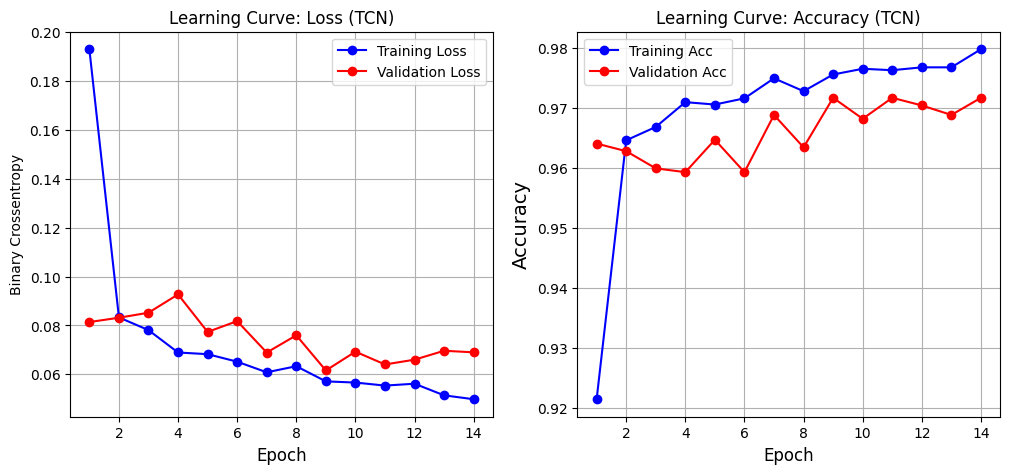

In [14]:


def plot_learning_curves(history_b):
    loss = history_b.history['loss']
    val_loss = history_b.history['val_loss']
    acc = history_b.history['accuracy']
    val_acc = history_b.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    # Plot 2: Loss (The Signal)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Learning Curve: Loss (TCN)')
    plt.ylabel('Binary Crossentropy')
    plt.xlabel('Epoch',fontsize =12)
    plt.legend()
    plt.grid(True)

    # Plot 1: Accuracy (The Goal: >80%)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Learning Curve: Accuracy (TCN)')
    plt.ylabel('Accuracy', fontsize = 14)
    plt.xlabel('Epoch',fontsize=12)
    plt.legend()
    plt.grid(True)

    

    plt.show()

# Call the function with your history object
plot_learning_curves(history_b)


# Phase 6: Hyperparameter Tuning (Task 2)
**Objective:** Using Keras Tuner (Random Search) to automatically discover the optimal architecture sizes and learning rates to prevent overfitting and maximize generalization on the validation set.

In [11]:
import keras_tuner as kt

def build_tunable_model(hp):
    """
    A dynamic CNN-LSTM model builder for keras Tuner.
    """

    model = Sequential()
    

    # CNN block
    # Tuning the number of filters in the first convolutional layer
    hp_filters_1 = hp.Int('conv_1_filters', min_value = 32, max_value =128, step = 32)
    model.add(Conv1D(filters = hp_filters_1, kernel_size= 3, activation = 'relu', padding = 'same',
                     input_shape = (x_train.shape[1], x_train.shape[2])))
    model.add(BatchNormalization())

    model.add(Conv1D(filters = 128, kernel_size = 3, activation = 'relu', padding ='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size = 2))

    #LSTM Block
    #Tuning the number of units in the primary LSTM layer
    hp_lstm_units = hp.Int('lstm_1_units', min_value =50, max_value =150,step =50)
    model.add(LSTM(units = hp_lstm_units, return_sequences = True,  activation = 'tanh' ))

    # Tuning the Dropout rate to find the exact sweet spot for regularization
    hp_dropout = hp.Float('dropout',min_value =0.2, max_value =0.5, step = 0.1)
    model.add(Dropout(hp_dropout))

    model.add(LSTM(units= 50, return_sequences =False, activation = 'tanh'))
    model.add(Dropout(hp_dropout))

    #classification Head
    model.add(Dense(units =32, activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))

    # Tuning the Learning rate
    hp_learning_rate = hp.Choice('learning_rate', values = [1e-2, 1e-3, 1e-4])

    optimizer = Adam(learning_rate = hp_learning_rate)
    model.compile(optimizer = optimizer, loss = 'binary_crossentropy',metrics =['accuracy'])

    return model


# Initialize the random Search Tuner
tuner = kt.RandomSearch(
    build_tunable_model,
    objective= 'val_loss', #optimize for lowest validation loss (least overfitting)
    max_trials =5,#test 5 different random combnations
    executions_per_trial =1,
    directory = 'tuning_dir',
    project_name = 'cmapss_cnn_lstm'
)

Reloading Tuner from tuning_dir/cmapss_cnn_lstm/tuner0.json


In [12]:
# 2. Run the Search
print(" Starting Hyperparameter Search on RTX 4050...")
tuner.search(x_train, y_train, epochs=20, validation_split=0.2, callbacks=[early_stop], verbose=1)

# 3. Extract the Best Model and Parameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
final_model = tuner.get_best_models(num_models=1)[0]

print(f"""
  Tuning Complete! The optimal architecture found:
- Convolutional Filters: {best_hps.get('conv_1_filters')}
- LSTM Units: {best_hps.get('lstm_1_units')}
- Dropout Rate: {best_hps.get('dropout')}
- Learning Rate: {best_hps.get('learning_rate')}
""")

Trial 5 Complete [00h 01m 37s]
val_loss: 0.09552988409996033

Best val_loss So Far: 0.0799650028347969
Total elapsed time: 00h 09m 26s

  Tuning Complete! The optimal architecture found:
- Convolutional Filters: 96
- LSTM Units: 50
- Dropout Rate: 0.30000000000000004
- Learning Rate: 0.01



/root/cmapss_predictive_maintenance/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


🚀 Building and Training the Final Optimized Model from scratch...


/root/cmapss_predictive_maintenance/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9439 - loss: 0.1434 - val_accuracy: 0.9561 - val_loss: 0.1103
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9547 - loss: 0.1106 - val_accuracy: 0.9590 - val_loss: 0.1033
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9603 - loss: 0.0905 - val_accuracy: 0.9711 - val_loss: 0.0718
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9629 - loss: 0.0947 - val_accuracy: 0.9714 - val_loss: 0.0663
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9611 - loss: 0.0918 - val_accuracy: 0.9670 - val_loss: 0.0888
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9642 - loss: 0.0910 - val_accuracy: 0.9504 - val_loss: 0.0907
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9635 - loss: 0.0889 - val_accuracy: 0.9679 - val_loss: 0.0809
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9671 - loss: 0.0763 - val_accu

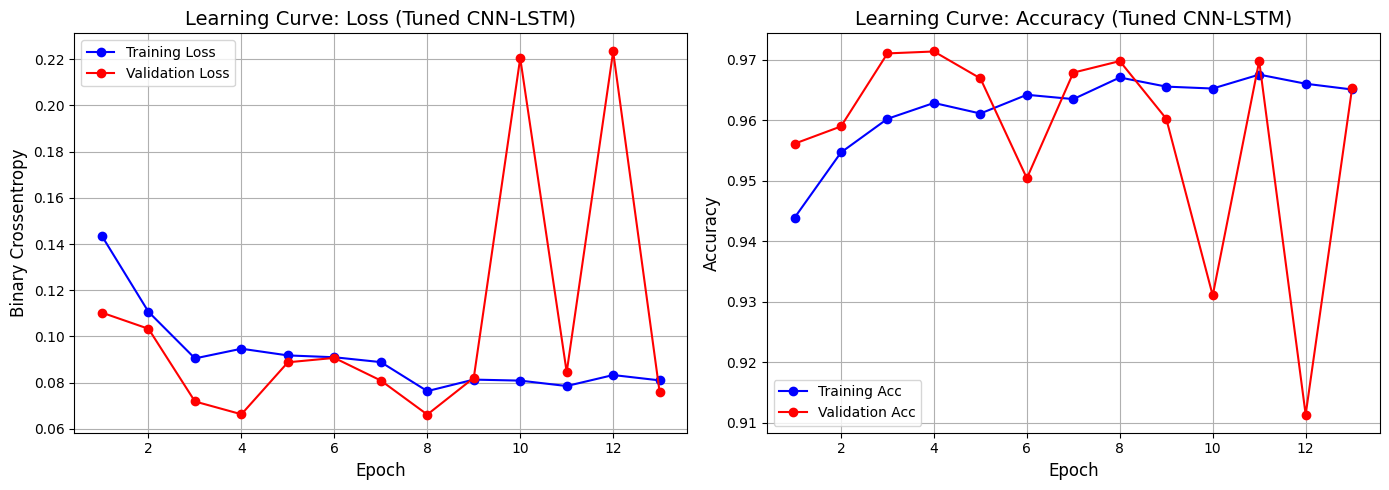

In [ ]:
#plotting function dynamic
def plot_learning_curves(history, model_name):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    
    # Plot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'Learning Curve: Loss ({model_name})', fontsize=14) 
    plt.ylabel('Binary Crossentropy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()
    plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title(f'Learning Curve: Accuracy ({model_name})', fontsize=14) 
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# 2. Rebuild a FRESH model using the best hyperparameters
print(" Building and Training the Final Optimized Model from scratch...")
final_model = tuner.hypermodel.build(best_hps)

# 3. Train it to get clean learning curves
history_final = final_model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop], # Uses the same early_stop from Phase 5
    verbose=1
)

# 4. Plot it!
plot_learning_curves(history_final, model_name="Tuned CNN-LSTM")

In [185]:
# 1 Configure Early Stopping
# This prevents the model from memorizing the data (overfitting)
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,               # If validation loss doesn't improve for 5 epochs, stop.
    restore_best_weights=True # Keep the best performing weights, not the final epoch's weights
)

In [ ]:

# 2. Rebuild a FRESH model using the best hyperparameters
print(" Building the Optimized Model (with manual LR stabilization)...")
final_model = tuner.hypermodel.build(best_hps)

# 2. OVERRIDE the Tuner's learning rate to make it stable
stable_optimizer = Adam(learning_rate=0.0002, clipnorm=1.0)
final_model.compile(
    optimizer=stable_optimizer, 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# 3. Train it to get clean learning curves
history_final = final_model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2, 
    callbacks=[early_stop], # Uses the same early_stop from Phase 5
    verbose=1
)


 Building the Final Optimized Model (with manual LR stabilization)...
Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9285 - loss: 0.2375 - val_accuracy: 0.1773 - val_loss: 0.7200
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9685 - loss: 0.0824 - val_accuracy: 0.3324 - val_loss: 0.6994
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9802 - loss: 0.0524 - val_accuracy: 0.9250 - val_loss: 0.1938
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9844 - loss: 0.0400 - val_accuracy: 0.9399 - val_loss: 0.1740
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9859 - loss: 0.0367 - val_accuracy: 0.9158 - val_loss: 0.2812
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9873 - loss: 0.0321 - val_accuracy: 0.9390 - val_loss: 0.2394
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9887 - loss: 0.0304 - val_accuracy: 0.9504 - val_loss: 0.1644
Epoch 8/50
197/197 ━━━━━━━━

In [119]:
# 1. Make your plotting function dynamic
def plot_learning_curves(history, model_name):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    
    # Plot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'Learning Curve: Loss ({model_name})', fontsize=14) 
    plt.ylabel('Binary Crossentropy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()
    plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title(f'Learning Curve: Accuracy ({model_name})', fontsize=14) 
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
# 4. Plot it!
#plot_learning_curves(history_final, model_name="Tuned CNN-LSTM")

In [ ]:

tf.keras.utils.set_random_seed(42) 
# This handles np.random, random.seed, and tf.random.set_seed in one go.

def build_tunable_model(hp):
    model = Sequential()
    
    # 1. Lower the filter range (e.g., 16 to 64) to prevent over-memorizing
    hp_filters_1 = hp.Int('conv_1_filters', min_value=16, max_value=64, step=16)
    model.add(Conv1D(filters=hp_filters_1, kernel_size=3, activation='relu', padding='same',
                     input_shape=(x_train.shape[1], x_train.shape[2])))
    model.add(BatchNormalization())
    
    # 2. Add Spatial Dropout after CNN
    model.add(tf.keras.layers.SpatialDropout1D(0.2)) 

    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # 3. Add recurrent_dropout to the LSTMs
    hp_lstm_units = hp.Int('lstm_1_units', min_value=32, max_value=128, step=32)
    model.add(LSTM(units=hp_lstm_units, return_sequences=True, activation='tanh', 
                   recurrent_dropout=0.2)) 

    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout))

    model.add(LSTM(units=32, return_sequences=False, activation='tanh', 
                   recurrent_dropout=0.2)) # 
    model.add(Dropout(hp_dropout))
    #classification Head
    model.add(Dense(units =32, activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))

    # Tuning the Learning rate
    hp_learning_rate = hp.Choice('learning_rate', values = [1e-2, 1e-3, 1e-4])

    optimizer = Adam(learning_rate = hp_learning_rate)
    model.compile(optimizer = optimizer, loss = 'binary_crossentropy',metrics =['accuracy'])

    return model

# Initialize the random Search Tuner
tuner = kt.RandomSearch(
    build_tunable_model,
    objective= 'val_loss', #optimize for lowest validation loss (least overfitting)
    max_trials =5,#test 5 different random combnations
    executions_per_trial =1,
    directory = 'tuning_dir',
    #project_name = 'cmapss_cnn_lstm'
    project_name='cmapss_v2_fresh'
)


In [78]:
# 2. Run the Search
print(" Starting Hyperparameter Search on RTX 4050...")
tuner.search(x_train, y_train, epochs=20, validation_split=0.2, callbacks=[early_stop], verbose=1)

# 3. Extract the Best Model and Parameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
final_model = tuner.get_best_models(num_models=1)[0]

print(f"""
  Tuning Complete! The optimal architecture found:
- Convolutional Filters: {best_hps.get('conv_1_filters')}
- LSTM Units: {best_hps.get('lstm_1_units')}
- Dropout Rate: {best_hps.get('dropout')}
- Learning Rate: {best_hps.get('learning_rate')}
""")

Trial 5 Complete [00h 00m 56s]
val_loss: 0.1364847868680954

Best val_loss So Far: 0.07470347732305527
Total elapsed time: 00h 05m 23s

  Tuning Complete! The optimal architecture found:
- Convolutional Filters: 64
- LSTM Units: 128
- Dropout Rate: 0.2
- Learning Rate: 0.001



In [202]:

# 2. Rebuild a FRESH model using the best hyperparameters
print(" Building the Final Optimized Model (with manual LR stabilization)...")
final_model = tuner.hypermodel.build(best_hps)

# Use this when training the final model
stable_optimizer = Adam(learning_rate=best_hps.get('learning_rate'), clipnorm=1.0)


final_model.compile(
    optimizer=stable_optimizer, 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# 3. Train it to get clean learning curves
history_final = final_model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2, 
    callbacks=[early_stop], # Uses the same early_stop from Phase 5
    verbose=1
)


 Building the Final Optimized Model (with manual LR stabilization)...


/root/cmapss_predictive_maintenance/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.9414 - loss: 0.1668 - val_accuracy: 0.1773 - val_loss: 0.8641
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9616 - loss: 0.0956 - val_accuracy: 0.8929 - val_loss: 0.2246
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9685 - loss: 0.0773 - val_accuracy: 0.9625 - val_loss: 0.0975
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9706 - loss: 0.0716 - val_accuracy: 0.9504 - val_loss: 0.1464
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9738 - loss: 0.0654 - val_accuracy: 0.9511 - val_loss: 0.1070
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9743 - loss: 0.0601 - val_accuracy: 0.9396 - val_loss: 0.1451
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9750 - loss: 0.0608 - val_accuracy: 0.9533 - val_loss: 0.1084
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9799 - loss: 0.0508 - val_acc

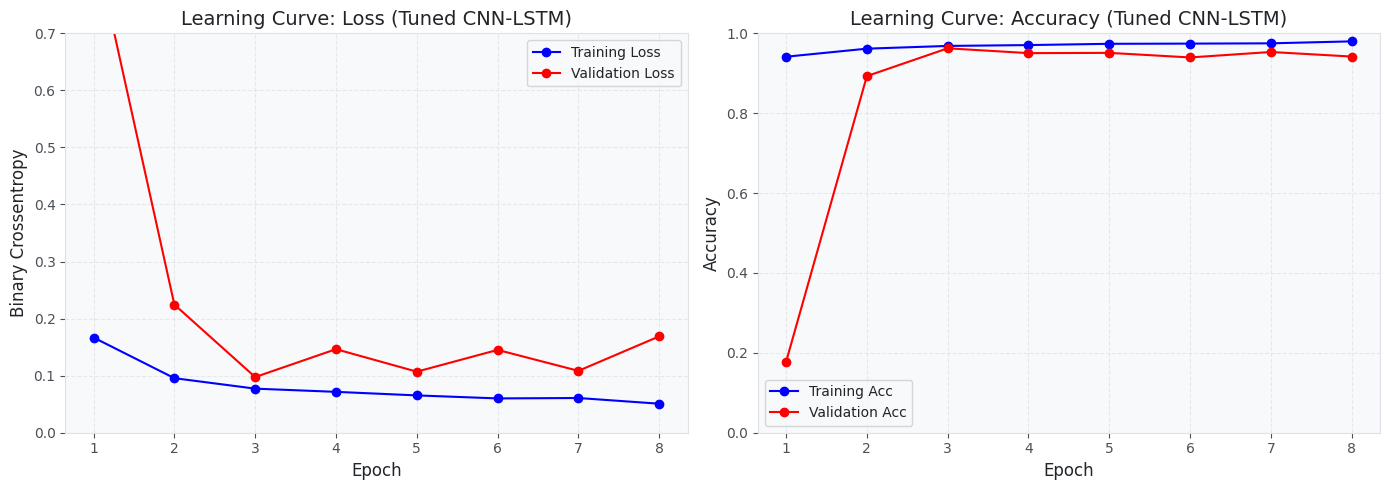

In [205]:
plot_learning_curves(history_final, model_name="Tuned CNN-LSTM")

# saving the final Model

In [139]:
import os

# Create a folder for our saved models if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the entire architecture, weights, and optimizer state
final_model.save('../models/cmapss_final_cnn_lstm.keras')
print(" Final model saved successfully to /models/cmapss_final_cnn_lstm.keras")

 Final model saved successfully to /models/cmapss_final_cnn_lstm.keras


In [ ]:
# 1. Make your plotting function dynamic
def plot_learning_curves(history, model_name):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    
    # Plot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title(f'Learning Curve: Loss ({model_name})', fontsize=14) 
    plt.ylabel('Binary Crossentropy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    
    
    plt.ylim(0, 0.7) # Sets (prevents zooming)
    
    plt.legend()
    plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title(f'Learning Curve: Accuracy ({model_name})', fontsize=14) 
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    
  
    plt.ylim(0, 1.0) #Sets accuracy view from 0% to 100%
    
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


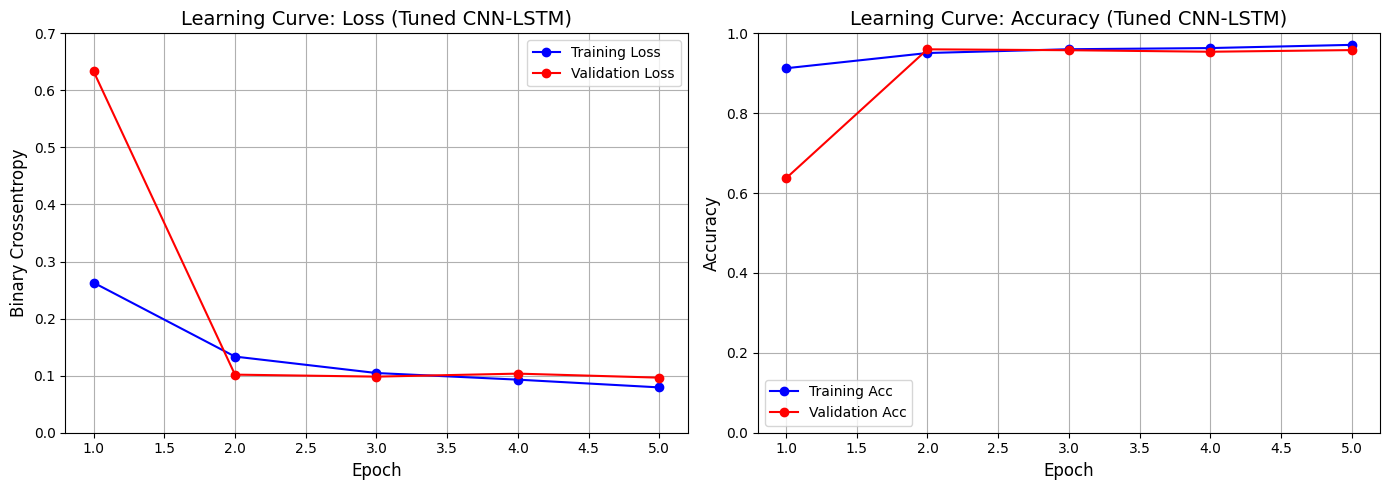

In [145]:
# 4. Plot it!
plot_learning_curves(history_final, model_name="Tuned CNN-LSTM")

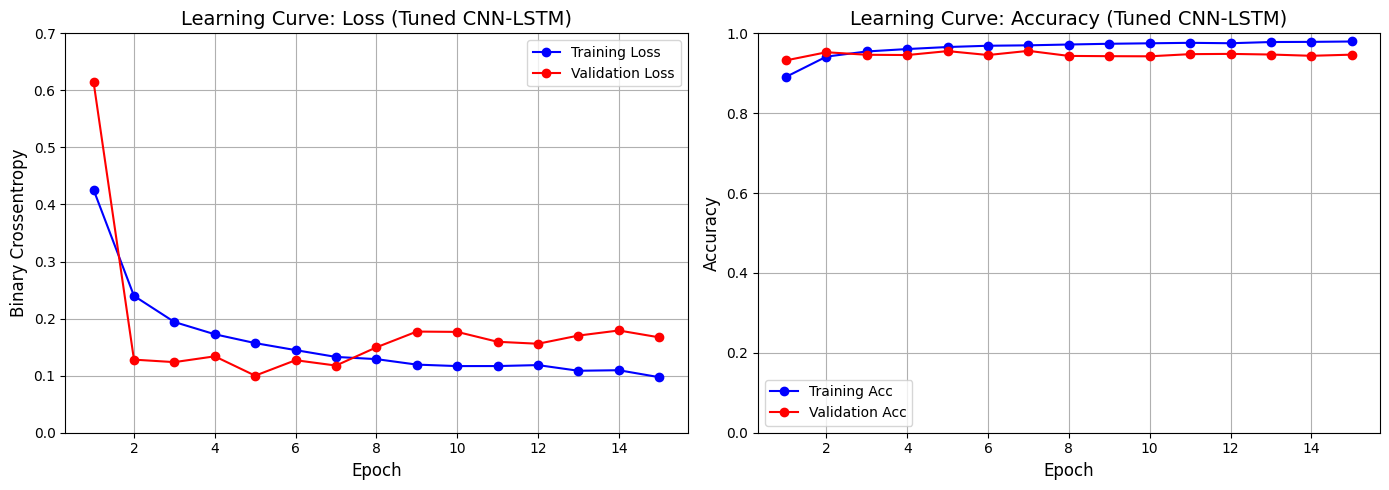

In [187]:
# 4. Plot it!
plot_learning_curves(history_final, model_name="Tuned CNN-LSTM")

In [ ]:
tf.keras.utils.set_random_seed(42)
print("Wiping old weights and building a fresh model...")
final_model = tuner.hypermodel.build(best_hps)


stable_optimizer = Adam(learning_rate=0.0001, clipnorm=0.5)

# 2. More patient LR scheduler — don't cut too early
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,      # was 3 — gives more room before cutting
    min_lr=1e-6,     # was 1e-7 — don't shrink into uselessness
    verbose=1
)

final_model.compile(
    optimizer=stable_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_final = final_model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,           # ←larger batch = smoother gradients = stabler val_loss
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        reduce_lr
    ],
    shuffle=True,
    class_weight={0: 1, 1: 3},
    verbose=1
)

Wiping old weights and building a fresh model...


/root/cmapss_predictive_maintenance/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.8663 - loss: 0.4989 - val_accuracy: 0.9282 - val_loss: 0.6503 - learning_rate: 1.0000e-04
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9296 - loss: 0.2789 - val_accuracy: 0.8351 - val_loss: 0.6123 - learning_rate: 1.0000e-04
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9490 - loss: 0.2024 - val_accuracy: 0.9558 - val_loss: 0.1493 - learning_rate: 1.0000e-04
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9561 - loss: 0.1649 - val_accuracy: 0.9650 - val_loss: 0.0900 - learning_rate: 1.0000e-04
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.9602 - loss: 0.1520 - val_accuracy: 0.9590 - val_loss: 0.0864 - learning_rate: 1.0000e-04
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9652 - loss: 0.1413 - val_accuracy: 0.9590 - val_loss: 0.0940 - learning_rate: 1.0000e-04
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - ac

In [ ]:
import os

# Create a folder for our saved models if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the entire architecture, weights, and optimizer state
final_model.save('../models/cmapss_final_cnn_lstm2.keras')
print(" Final model saved successfully to /models/cmapss_final_cnn_lstm2.keras")

 Final model saved successfully to /models/cmapss_final_cnn_lstm.keras


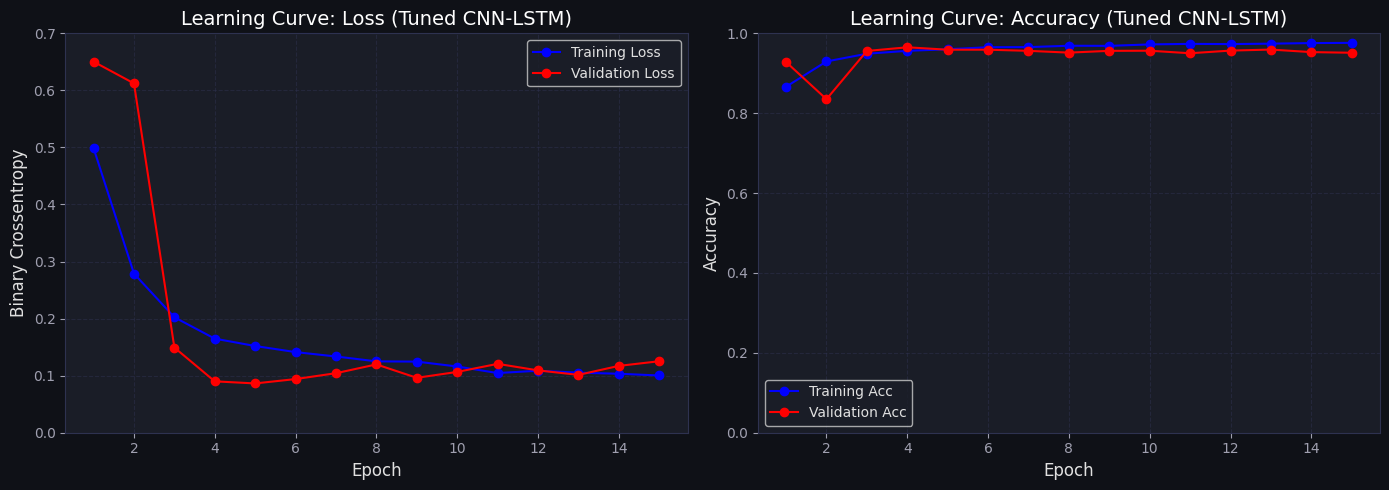

In [194]:
# 4. Plot it!
plot_learning_curves(history_final, model_name="Tuned CNN-LSTM")

Loading the perfectly tuned model from disk...
 Generating Predictions on Unseen Data...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step

--- Testing Decision Thresholds ---

 Optimal Threshold (Recall-First): 0.10
   Recall:    1.0000  ← primary objective
   Precision: 0.8333
   F1-Score:  0.9091

--- Applying Threshold 0.10 ---

=== FINAL OPTIMIZED RESULTS (Recall-First) ===
Accuracy:  0.9500  (informational only)
Precision: 0.8333
Recall:    1.0000  ← what we optimized for
F1-Score:  0.9091


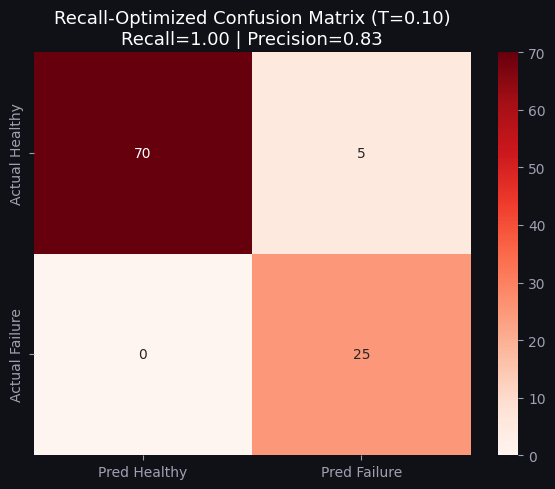

In [ ]:
from tensorflow.keras.models import load_model

print("Loading the perfectly tuned model from disk...")
# This completely overwrites whatever was in your notebook's memory
# with the physical file you saved earlier!
guaranteed_final_model = load_model('../models/cmapss_final_cnn_lstm2.keras')

print(" Generating Predictions on Unseen Data...")
# Use the newly loaded model here
y_pred_prob = guaranteed_final_model.predict(X_test_final)



# --- 2. Find the optimal threshold (Recall-First Strategy) ---
print("\n--- Testing Decision Thresholds ---")

thresholds = np.arange(0.1, 0.9, 0.01)

best_recall    = 0
best_t         = 0.5
best_prec_for_t = 0
best_f1_for_t  = 0

MIN_PRECISION = 0.45  # Guard against a degenerate "predict everything as failure" model

for t in thresholds:
    temp_pred = (y_pred_prob >= t).astype(int).flatten()
    temp_prec = precision_score(y_test_true, temp_pred, zero_division=0)
    temp_rec  = recall_score(y_test_true, temp_pred, zero_division=0)
    temp_f1   = f1_score(y_test_true, temp_pred, zero_division=0)

    # Primary gate: precision must stay meaningful (not just flagging everything)
    if temp_prec >= MIN_PRECISION:
        # Primary objective: maximize recall (catch every engine failure you can)
        if temp_rec > best_recall:
            best_recall    = temp_rec
            best_prec_for_t = temp_prec
            best_f1_for_t  = temp_f1
            best_t         = t

print(f"\n Optimal Threshold (Recall-First): {best_t:.2f}")
print(f"   Recall:    {best_recall:.4f}  ← primary objective")
print(f"   Precision: {best_prec_for_t:.4f}")
print(f"   F1-Score:  {best_f1_for_t:.4f}")

# --- 3. Apply the Best Threshold ---
print(f"\n--- Applying Threshold {best_t:.2f} ---")
y_pred_final = (y_pred_prob >= best_t).astype(int).flatten()

# --- 4. Final Reporting ---
final_acc  = accuracy_score(y_test_true, y_pred_final)
final_prec = precision_score(y_test_true, y_pred_final, zero_division=0)
final_rec  = recall_score(y_test_true, y_pred_final, zero_division=0)
final_f1   = f1_score(y_test_true, y_pred_final, zero_division=0)

print("\n=== FINAL OPTIMIZED RESULTS (Recall-First) ===")
print(f"Accuracy:  {final_acc:.4f}  (informational only)")
print(f"Precision: {final_prec:.4f}")
print(f"Recall:    {final_rec:.4f}  ← what we optimized for")
print(f"F1-Score:  {final_f1:.4f}")

# --- 5. Plot ---
cm = confusion_matrix(y_test_true, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Pred Healthy', 'Pred Failure'],
            yticklabels=['Actual Healthy', 'Actual Failure'])
plt.title(f'Recall-Optimized Confusion Matrix (T={best_t:.2f})\nRecall={final_rec:.2f} | Precision={final_prec:.2f}')
plt.tight_layout()
plt.show()

Loading the perfectly tuned model from disk...
Generating Predictions on Unseen Data...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step

--- Scanning for Best Recall Threshold ---
Auto-Calculated Optimal Threshold: 0.10

>>> OVERRIDE ACTIVE: Using Manual Threshold (0.15)

=== FINAL RESULTS ===
Threshold Used: 0.15
Accuracy:       0.9700
Precision:      0.8929
Recall:         1.0000
F1-Score:       0.9434


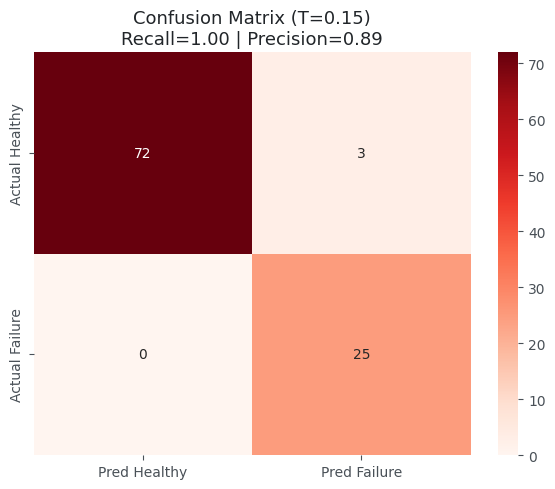

In [210]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- 1. Load Model & Generate Probabilities ---
print("Loading the perfectly tuned model from disk...")
guaranteed_final_model = load_model('../models/cmapss_final_cnn_lstm2.keras')

print("Generating Predictions on Unseen Data...")
y_pred_prob = guaranteed_final_model.predict(X_test_final)

# --- 2. Automatic Optimization (Informational) ---
print("\n--- Scanning for Best Recall Threshold ---")
thresholds = np.arange(0.1, 0.9, 0.01)
best_recall = 0
best_t_auto = 0.5
MIN_PRECISION = 0.45

for t in thresholds:
    temp_pred = (y_pred_prob >= t).astype(int).flatten()
    temp_prec = precision_score(y_test_true, temp_pred, zero_division=0)
    temp_rec  = recall_score(y_test_true, temp_pred, zero_division=0)
    
    if temp_prec >= MIN_PRECISION:
        if temp_rec > best_recall:
            best_recall = temp_rec
            best_t_auto = t

print(f"Auto-Calculated Optimal Threshold: {best_t_auto:.2f}")

# ==============================================================================
# --- 3. MANUAL OVERRIDE (CONTROL PANEL) ---
# Change this value to 0.15, 0.20, or 0.5 to see different results.
# Set to None to use the Auto-Calculated value above.
# ==============================================================================

FORCE_THRESHOLD = 0.15   # <--- CHANGE THIS NUMBER HERE

# Logic to pick the final threshold
if FORCE_THRESHOLD is not None:
    final_t = FORCE_THRESHOLD
    print(f"\n>>> OVERRIDE ACTIVE: Using Manual Threshold ({final_t:.2f})")
else:
    final_t = best_t_auto
    print(f"\n>>> AUTO MODE: Using Optimized Threshold ({final_t:.2f})")

# ==============================================================================


# --- 4. Apply Final Threshold & Report ---
y_pred_final = (y_pred_prob >= final_t).astype(int).flatten()

final_acc  = accuracy_score(y_test_true, y_pred_final)
final_prec = precision_score(y_test_true, y_pred_final, zero_division=0)
final_rec  = recall_score(y_test_true, y_pred_final, zero_division=0)
final_f1   = f1_score(y_test_true, y_pred_final, zero_division=0)

print("\n=== FINAL RESULTS ===")
print(f"Threshold Used: {final_t:.2f}")
print(f"Accuracy:       {final_acc:.4f}")
print(f"Precision:      {final_prec:.4f}")
print(f"Recall:         {final_rec:.4f}")
print(f"F1-Score:       {final_f1:.4f}")

# --- 5. Plot Confusion Matrix ---
cm = confusion_matrix(y_test_true, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Pred Healthy', 'Pred Failure'],
            yticklabels=['Actual Healthy', 'Actual Failure'])
plt.title(f'Confusion Matrix (T={final_t:.2f})\nRecall={final_rec:.2f} | Precision={final_prec:.2f}')
plt.tight_layout()
plt.show()


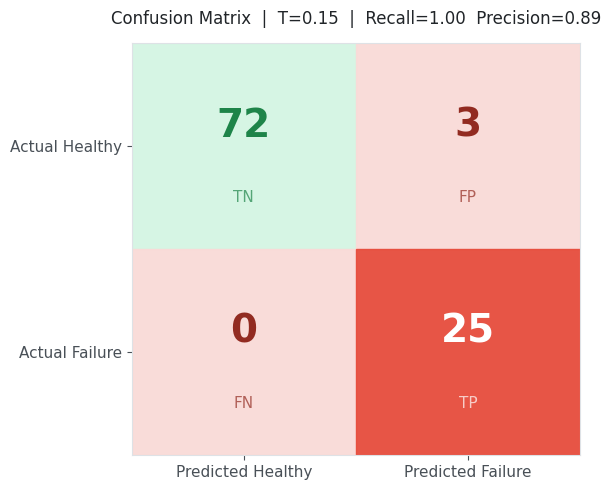

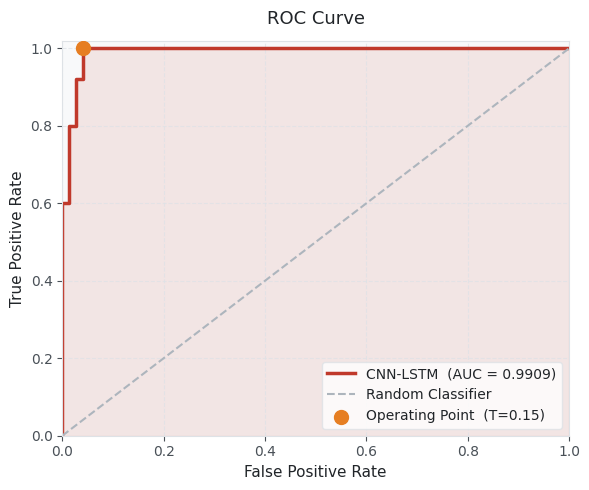

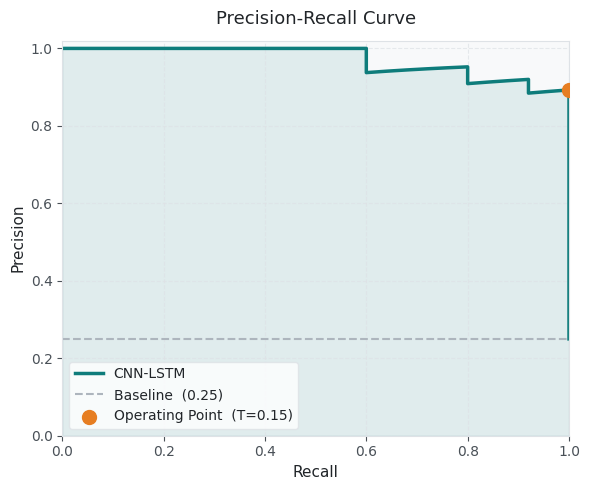

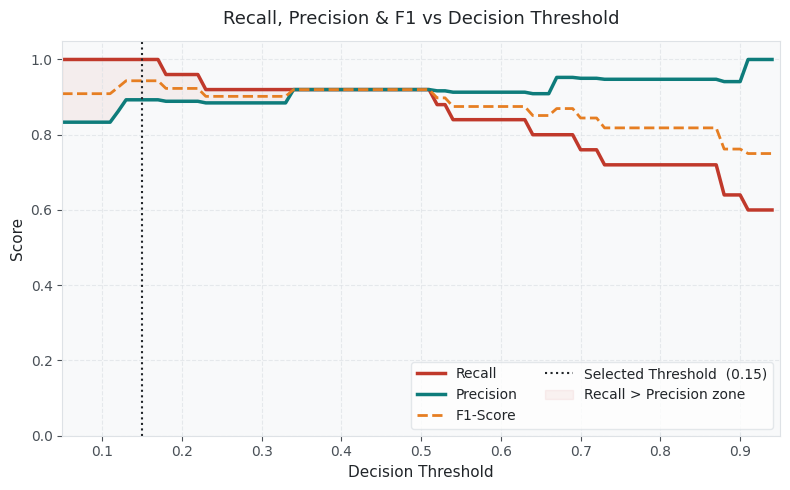

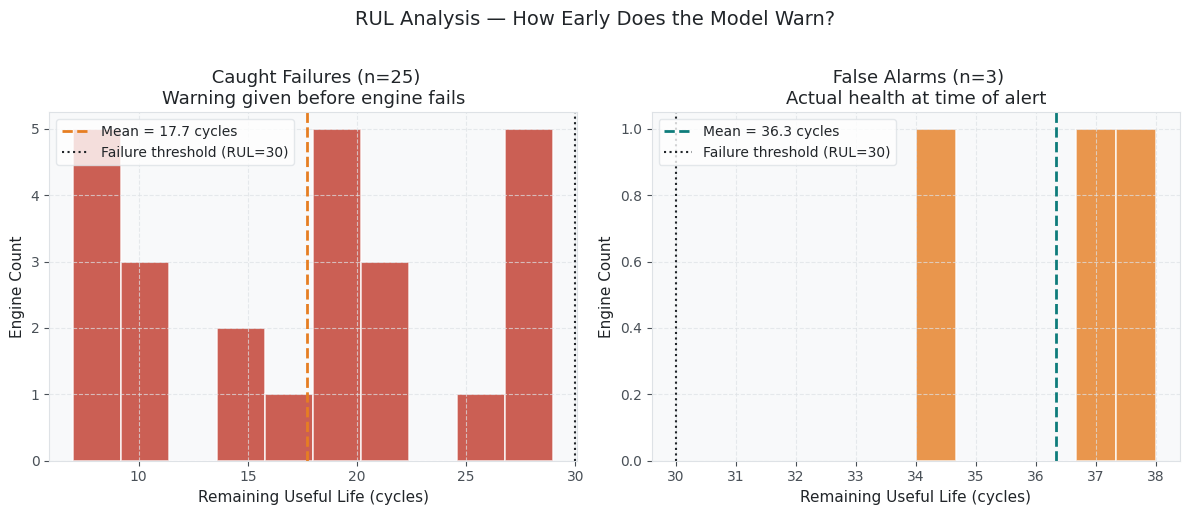

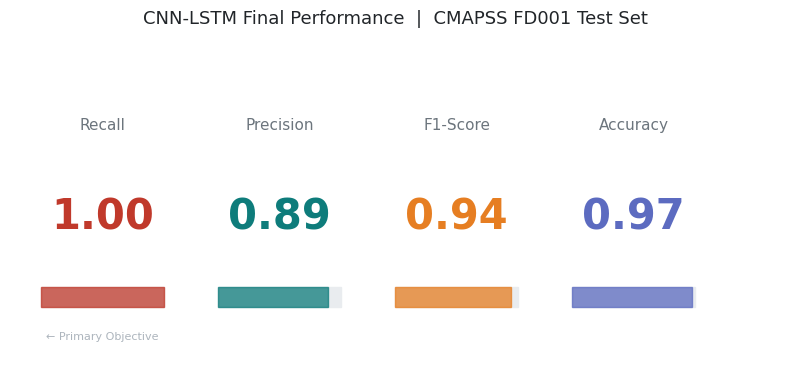


 All 7 report plots saved to disk.


In [211]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import numpy as np
import seaborn as sns
import pandas as pd

# ── Global Style (White Theme) ───────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#ffffff',
    'axes.facecolor'    : '#f8f9fa',
    'axes.edgecolor'    : '#dee2e6',
    'axes.labelcolor'   : '#212529',
    'axes.titlecolor'   : '#212529',
    'xtick.color'       : '#495057',
    'ytick.color'       : '#495057',
    'text.color'        : '#212529',
    'grid.color'        : '#dee2e6',
    'grid.linestyle'    : '--',
    'grid.alpha'        : 0.7,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
})

CRIMSON  = '#c0392b'
TEAL     = '#0e7c7b'
AMBER    = '#e67e22'
LAVENDER = '#5c6bc0'
BLACK    = '#212529'

# ════════════════════════════════════════════════════════════════
# PLOT 1 — Confusion Matrix
# ════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#ffffff')

cm = confusion_matrix(y_test_true, y_pred_final)
labels = [['TN', 'FP'], ['FN', 'TP']]
colors = [['#d5f5e3', '#fadbd8'], ['#fadbd8', '#e74c3c']]
text_colors = [['#1e8449', '#922b21'], ['#922b21', '#ffffff']]

for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, 1-i), 1, 1,
                     color=colors[i][j], alpha=0.95, zorder=1))
        ax.text(j + 0.5, 1 - i + 0.6, str(cm[i, j]),
                ha='center', va='center', fontsize=28,
                fontweight='bold', color=text_colors[i][j], zorder=2)
        ax.text(j + 0.5, 1 - i + 0.25, labels[i][j],
                ha='center', va='center', fontsize=11,
                color=text_colors[i][j], zorder=2, alpha=0.7)

ax.set_xlim(0, 2); ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(['Predicted Healthy', 'Predicted Failure'], fontsize=11)
ax.set_yticklabels(['Actual Failure', 'Actual Healthy'], fontsize=11)
ax.set_title(f'Confusion Matrix  |  T={final_t:.2f}  |  Recall={final_rec:.2f}  Precision={final_prec:.2f}',
             fontsize=12, pad=14, color=BLACK)
plt.tight_layout()
plt.savefig('report_confusion_matrix.png', dpi=200,
            bbox_inches='tight', facecolor='#ffffff')
plt.show()

# ════════════════════════════════════════════════════════════════
# PLOT 2 — ROC Curve
# ════════════════════════════════════════════════════════════════
fpr, tpr, _ = roc_curve(y_test_true, y_pred_prob)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#ffffff')

ax.fill_between(fpr, tpr, alpha=0.10, color=CRIMSON)
ax.plot(fpr, tpr, color=CRIMSON, lw=2.5, label=f'CNN-LSTM  (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='#adb5bd', lw=1.5, linestyle='--', label='Random Classifier')
ax.scatter([fpr[np.argmin(np.abs(tpr - final_rec))]],
           [final_rec], color=AMBER, s=100, zorder=5,
           label=f'Operating Point  (T={final_t:.2f})')

ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', pad=12)
ax.legend(loc='lower right', facecolor='#ffffff', edgecolor='#dee2e6')
ax.grid(True); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('report_roc_curve.png', dpi=200,
            bbox_inches='tight', facecolor='#ffffff')
plt.show()

# ════════════════════════════════════════════════════════════════
# PLOT 3 — Precision-Recall Curve
# ════════════════════════════════════════════════════════════════
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test_true, y_pred_prob)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#ffffff')

ax.fill_between(recall_curve, precision_curve, alpha=0.10, color=TEAL)
ax.plot(recall_curve, precision_curve, color=TEAL, lw=2.5, label='CNN-LSTM')
ax.axhline(y=y_test_true.mean(), color='#adb5bd', linestyle='--',
           lw=1.5, label=f'Baseline  ({y_test_true.mean():.2f})')
ax.scatter([final_rec], [final_prec], color=AMBER, s=100, zorder=5,
           label=f'Operating Point  (T={final_t:.2f})')

ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', pad=12)
ax.legend(facecolor='#ffffff', edgecolor='#dee2e6')
ax.grid(True); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig('report_pr_curve.png', dpi=200,
            bbox_inches='tight', facecolor='#ffffff')
plt.show()

# ════════════════════════════════════════════════════════════════
# PLOT 4 — Threshold Analysis
# ════════════════════════════════════════════════════════════════
thresh_range = np.arange(0.05, 0.95, 0.01)
rec_vals, prec_vals, f1_vals = [], [], []

for t in thresh_range:
    p = (y_pred_prob >= t).astype(int).flatten()
    rec_vals.append(recall_score(y_test_true, p, zero_division=0))
    prec_vals.append(precision_score(y_test_true, p, zero_division=0))
    f1_vals.append(f1_score(y_test_true, p, zero_division=0))

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#ffffff')

ax.plot(thresh_range, rec_vals,  color=CRIMSON, lw=2.5, label='Recall')
ax.plot(thresh_range, prec_vals, color=TEAL,    lw=2.5, label='Precision')
ax.plot(thresh_range, f1_vals,   color=AMBER,   lw=2,   label='F1-Score', linestyle='--')
ax.axvline(final_t, color=BLACK, linestyle=':', lw=1.5,
           label=f'Selected Threshold  ({final_t:.2f})')
ax.fill_between(thresh_range, rec_vals, prec_vals,
                where=[r > p for r, p in zip(rec_vals, prec_vals)],
                alpha=0.06, color=CRIMSON, label='Recall > Precision zone')

ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.set_title('Recall, Precision & F1 vs Decision Threshold', pad=12)
ax.legend(facecolor='#ffffff', edgecolor='#dee2e6', ncol=2)
ax.grid(True); ax.set_xlim(0.05, 0.95); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('report_threshold_analysis.png', dpi=200,
            bbox_inches='tight', facecolor='#ffffff')
plt.show()

# ════════════════════════════════════════════════════════════════
# PLOT 5 — RUL Distribution
# ════════════════════════════════════════════════════════════════
truth_df   = pd.read_csv('../data/raw/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])
rul_values = truth_df['RUL'].values

true_positive_mask  = (y_test_true == 1) & (y_pred_final == 1)
false_positive_mask = (y_test_true == 0) & (y_pred_final == 1)
tp_ruls = rul_values[true_positive_mask]
fp_ruls = rul_values[false_positive_mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#ffffff')

axes[0].hist(tp_ruls, bins=10, color=CRIMSON, edgecolor='#ffffff',
             alpha=0.80, linewidth=1.2)
axes[0].axvline(tp_ruls.mean(), color=AMBER, linestyle='--', lw=2,
                label=f'Mean = {tp_ruls.mean():.1f} cycles')
axes[0].axvline(30, color=BLACK, linestyle=':', lw=1.5,
                label='Failure threshold (RUL=30)')
axes[0].set_xlabel('Remaining Useful Life (cycles)')
axes[0].set_ylabel('Engine Count')
axes[0].set_title(f' Caught Failures (n={len(tp_ruls)})\nWarning given before engine fails')
axes[0].legend(facecolor='#ffffff', edgecolor='#dee2e6')
axes[0].grid(True)

axes[1].hist(fp_ruls, bins=6, color=AMBER, edgecolor='#ffffff',
             alpha=0.80, linewidth=1.2)
axes[1].axvline(fp_ruls.mean(), color=TEAL, linestyle='--', lw=2,
                label=f'Mean = {fp_ruls.mean():.1f} cycles')
axes[1].axvline(30, color=BLACK, linestyle=':', lw=1.5,
                label='Failure threshold (RUL=30)')
axes[1].set_xlabel('Remaining Useful Life (cycles)')
axes[1].set_ylabel('Engine Count')
axes[1].set_title(f' False Alarms (n={len(fp_ruls)})\nActual health at time of alert')
axes[1].legend(facecolor='#ffffff', edgecolor='#dee2e6')
axes[1].grid(True)

plt.suptitle('RUL Analysis — How Early Does the Model Warn?',
             fontsize=14, color=BLACK, y=1.02)
plt.tight_layout()
plt.savefig('report_rul_analysis.png', dpi=200,
            bbox_inches='tight', facecolor='#ffffff')
plt.show()



# ════════════════════════════════════════════════════════════════
# PLOT 7 — Final Metrics Summary Card
# ════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#ffffff')
ax.axis('off')

metrics = [
    ('Recall',    final_rec,  CRIMSON,   '← Primary Objective'),
    ('Precision', final_prec, TEAL,      ''),
    ('F1-Score',  final_f1,   AMBER,     ''),
    ('Accuracy',  final_acc,  LAVENDER,  ''),
]

for i, (name, val, color, note) in enumerate(metrics):
    x = 0.12 + i * 0.23
    ax.text(x, 0.75, name, ha='center', fontsize=11,
            color='#6c757d', transform=ax.transAxes)
    ax.text(x, 0.45, f'{val:.2f}', ha='center', fontsize=30,
            fontweight='bold', color=color, transform=ax.transAxes)
    bar_w = 0.16
    ax.add_patch(plt.Rectangle((x - bar_w/2, 0.22), bar_w * val, 0.06,
                 color=color, alpha=0.75, transform=ax.transAxes, zorder=2))
    ax.add_patch(plt.Rectangle((x - bar_w/2, 0.22), bar_w, 0.06,
                 color='#e9ecef', transform=ax.transAxes, zorder=1))
    if note:
        ax.text(x, 0.12, note, ha='center', fontsize=8,
                color='#adb5bd', transform=ax.transAxes)

ax.set_title('CNN-LSTM Final Performance  |  CMAPSS FD001 Test Set',
             fontsize=13, color=BLACK, pad=16)
plt.tight_layout()
plt.savefig('report_metrics_summary.png', dpi=200,
            bbox_inches='tight', facecolor='#ffffff')
plt.show()

print("\n All 7 report plots saved to disk.")